In [1]:
import sys
import os

# Add the root project directory to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

## Load and Clean Data

In [2]:
from src.data_cleaner import check_missing_values, convert_types, drop_useless_columns, fill_missing_values, remove_invalid_premiums
from src.data_analyzer import describe_numerical, compute_loss_ratio
from src.data_visualizer import plot_hist_and_box, plot_claims_over_time, plot_top_and_bottom_models_by_claims
from src.data_loader import load_data

In [3]:
df = load_data("../data/MachineLearningRating_v3/MachineLearningRating_v3.txt")

✅ Loaded data with shape: (1000098, 52)


In [4]:
df.head(2)

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0


In [4]:
# datetime conversion
df = convert_types(df)

In [6]:
# check missing values
print(check_missing_values(df))

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Converted                   641901
Rebuilt                     641901
WrittenOff                  641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
Cylinders                      552
cubiccapacity                  552
kilowatts                      552
NumberOfDoors                  552
VehicleIntroDate               552
Model                          552
make                           552
VehicleType                    552
mmcode                         552
bodytype                       552
CapitalOutstanding               2
dtype: int64


In [5]:
#  drop useless columns
df = drop_useless_columns(df, ['NumberOfVehiclesInFleet', 'CrossBorder'])

In [6]:
# fill missing values and drop rows with missing target values
df = fill_missing_values(df)

📥 Original shape: (1000098, 50)
✅ Cleaned shape: (999544, 50)
🧹 Rows removed during cleaning: 554


In [9]:
# check missing values again
print(check_missing_values(df))

Series([], dtype: int64)


In [7]:
# data where totalpremium is not less than zero or not zero
df = remove_invalid_premiums(df)

🧹 Removed 381588 rows with TotalPremium <= 0


In [8]:
# revome rows with negative claims
df = df[df['TotalClaims'] >= 0]

## Data Structure & Summary Stats

In [12]:
# check types
print("Data types:")
df.dtypes

Data types:


UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[ns]
IsVATRegistered                       bool
Citizenship                         object
LegalType                           object
Title                               object
Language                            object
Bank                                object
AccountType                         object
MaritalStatus                       object
Gender                              object
Country                             object
Province                            object
PostalCode                           int64
MainCrestaZone                      object
SubCrestaZone                       object
ItemType                            object
mmcode                             float64
VehicleType                         object
RegistrationYear                     int64
make                                object
Model                               object
Cylinders  

In [16]:
# Descriptive statistics
print("Descriptive statistics:")
describe_numerical(df)

Descriptive statistics:


,UnderwrittenCoverID,PolicyID,TransactionMonth,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,617954.000000,617954.000000,617954,617954.000000,6.179540e+05,617954.000000,617954.000000,617954.000000,617954.000000,617954.000000,6.179540e+05,6.179540e+05,617954.000000,617954.000000,617954.000000
mean,115053.246216,8727.663936,2015-03-05 19:25:58.030533376,2970.455463,5.535210e+07,2010.225957,4.044599,2487.076983,97.650856,4.013451,5.841715e+04,6.096145e+05,117.402830,99.319100,99.577117
min,13.000000,14.000000,2013-10-01 00:00:00,1.000000,4.041640e+06,1987.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000e-02,0.000200,0.000011,0.000000
25%,71571.000000,5184.000000,2015-01-01 00:00:00,742.000000,6.005692e+07,2008.000000,4.000000,2237.000000,75.000000,4.000000,0.000000e+00,5.000000e+03,3.255100,2.631316,0.000000
50%,111176.000000,7445.000000,2015-04-01 00:00:00,2000.000000,6.005842e+07,2011.000000,4.000000,2694.000000,111.000000,4.000000,0.000000e+00,7.500000e+03,8.435000,7.275088,0.000000
75%,146852.000000,11988.000000,2015-06-01 00:00:00,4126.000000,6.005842e+07,2013.000000,4.000000,2694.000000,111.000000,4.000000,4.000000e+04,2.505000e+05,90.000000,78.947368,0.000000
max,301175.000000,23246.000000,2015-08-01 00:00:00,9870.000000,6.506535e+07,2015.000000,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,1.000000e+07,2568.998300,2253.507281,393092.105263
std,64833.472967,5436.337959,NaN,2608.041459,1.294134e+07,3.270338,0.288604,394.828046,19.023005,0.452315,3.501629e+05,1.514581e+06,221.928366,189.950489,2970.913035


In [10]:
# save cleaned data
df.to_csv("../data/processed/cleaned_insurance_data.csv", index=False)

## Distribution + Outlier Detection

What are the distributions of key financial variables?

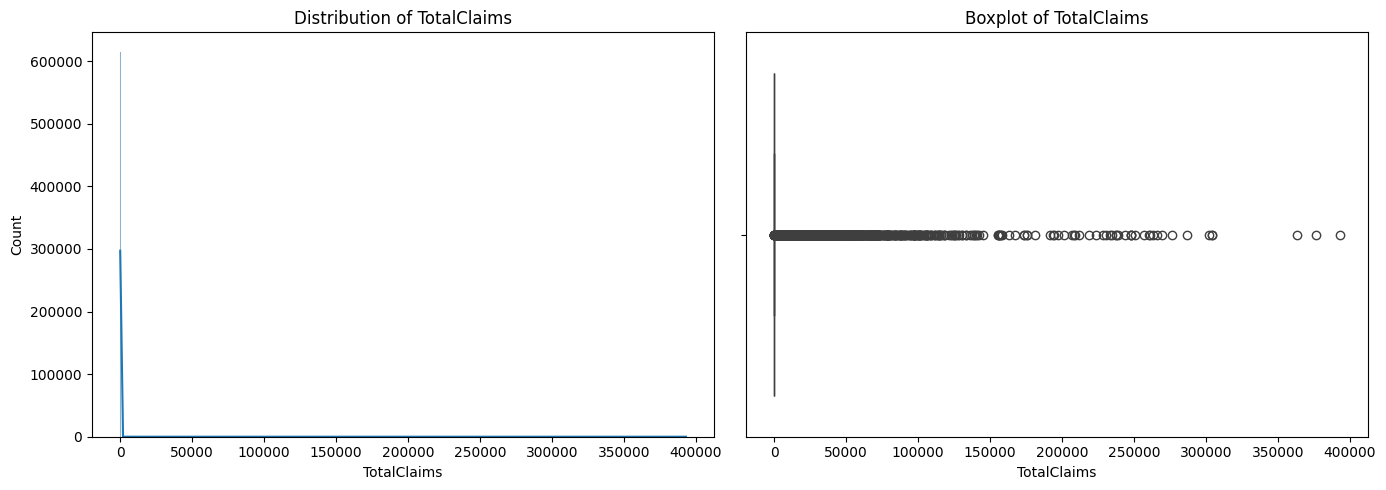

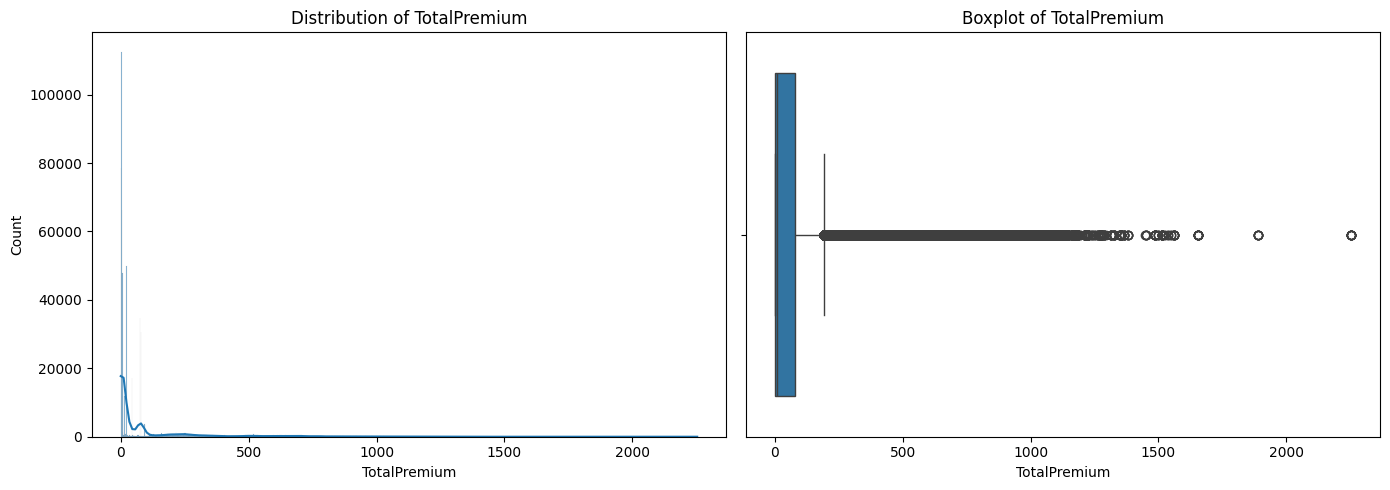

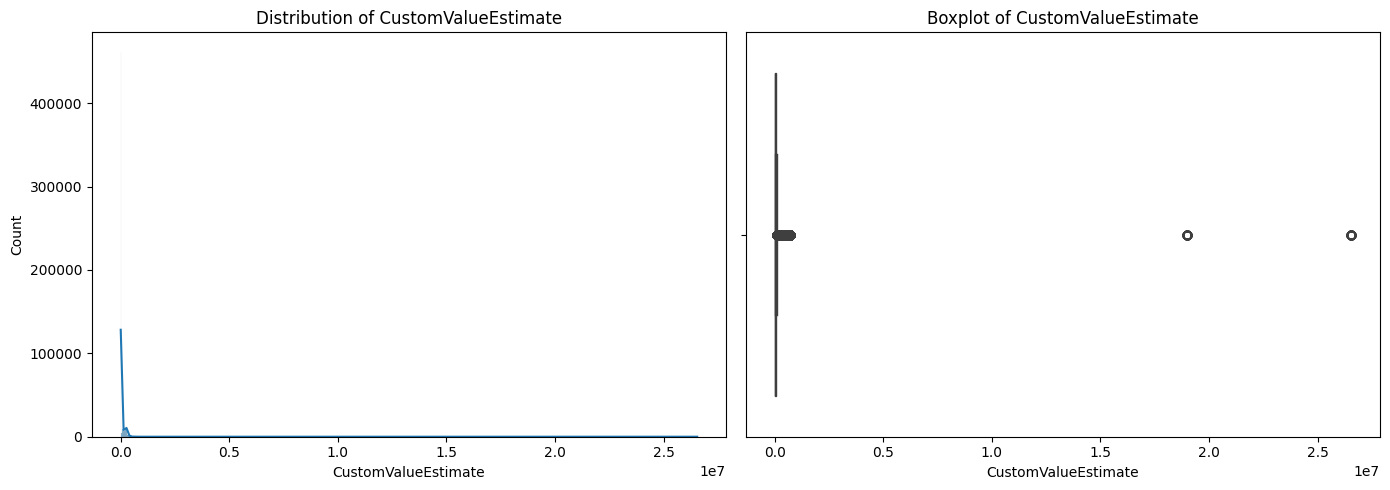

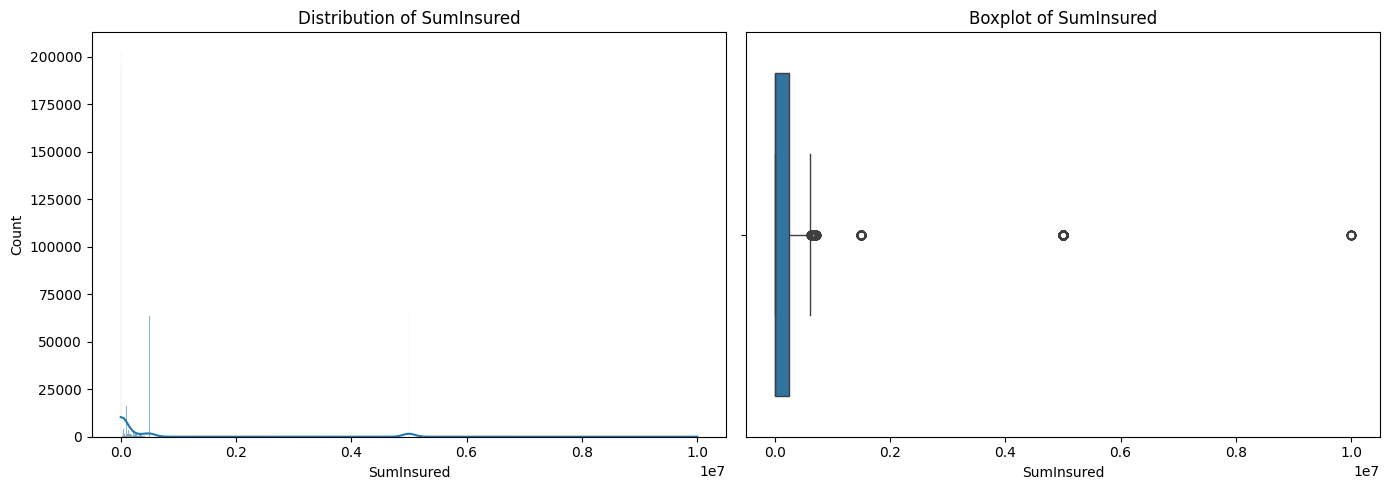

In [19]:
for col in ['TotalClaims', 'TotalPremium', 'CustomValueEstimate', 'SumInsured']:
    plot_hist_and_box(df, col)

## Correlation Heatmap

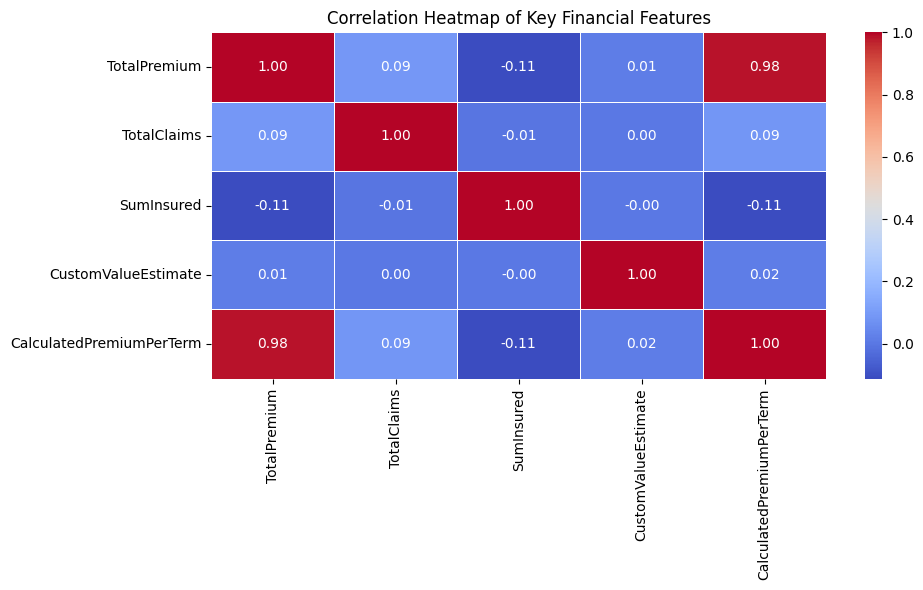

In [9]:
from src.data_visualizer import correlation_heatmap
correlation_heatmap(df)

## Trend Over Time

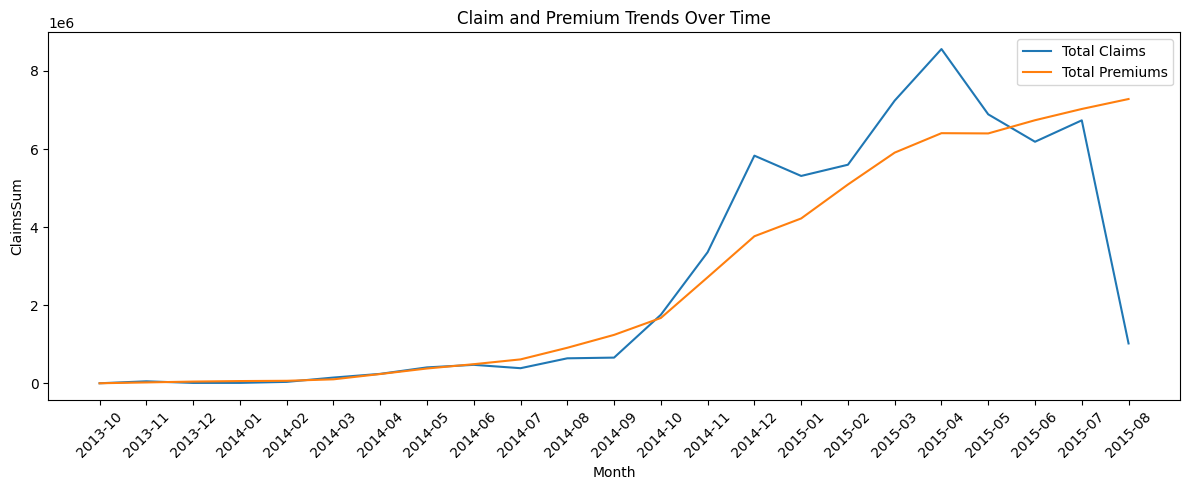

In [21]:
plot_claims_over_time(df)

## Loss Ratio Analysis

📉 Loss Ratio by Region, VehicleType, Gender:
         Province        VehicleType         Gender  LossRatio
45  Northern Cape   Heavy Commercial  Not specified   2.172783
2    Eastern Cape  Medium Commercial  Not specified   1.684985
9         Gauteng   Light Commercial  Not specified   1.569932
51   Western Cape   Heavy Commercial  Not specified   1.459208
31     Mpumalanga   Heavy Commercial  Not specified   1.235708


c:\ME\KAIM\acis-insurance-risk-analytics\src\data_visualizer.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x="LossRatio", y="Group", palette="coolwarm")


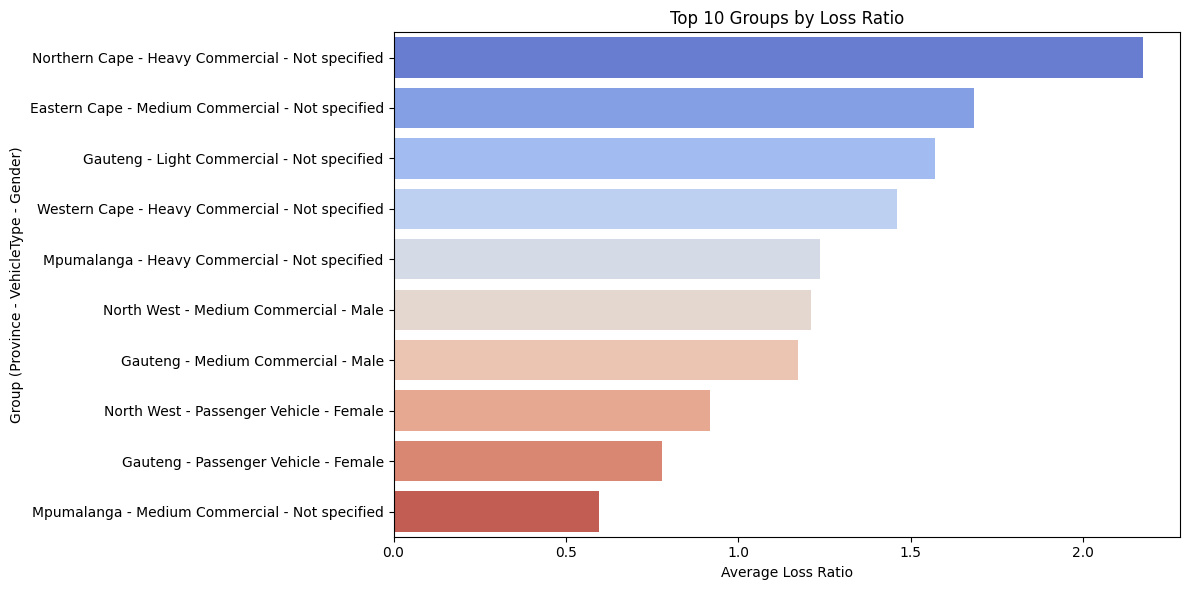

In [12]:
# Loss ratio computation
loss_ratios = compute_loss_ratio(df)
print("📉 Loss Ratio by Region, VehicleType, Gender:")
print(loss_ratios.head())

from src.data_visualizer import plot_top_loss_ratios
plot_top_loss_ratios(loss_ratios, top_n=10)


## Vehicle Model Analysis

Which vehicle make/models have highest and lowest claim amounts?

🚗 Top Claiming Models:
                                  make                        Model  \
0                              HYUNDAI       H-1 2.5 CRDI WAGON A/T   
1                               TOYOTA  L/CRUISER FJ 4.0 V6 CRUISER   
2                               TOYOTA                 VERSO 180 SX   
3                                  BMW                   320d (E90)   
4                                 FIAT       DUCATO 2.3 JTD VETRATO   
5  SUZUKI                                             ERTIGA 1.4 GA   
6                        MERCEDES-BENZ                C180 BE COUPE   
7                                MAZDA             3 2.0 INDIVIDUAL   
8                           VOLKSWAGEN            POLO VIVO 1.6 5Dr   
9                                 AUDI  A4 1.8T S AVANT MULTITRONIC   

   TotalClaims  
0  6177.271564  
1  5340.970273  
2  5222.270335  
3  1253.318881  
4  1014.681021  
5   993.628225  
6   893.975272  
7   860.246711  
8   827.558882  
9   803.591711  


c:\ME\KAIM\acis-insurance-risk-analytics\src\data_visualizer.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="TotalClaims", data=top, palette="Reds_r")


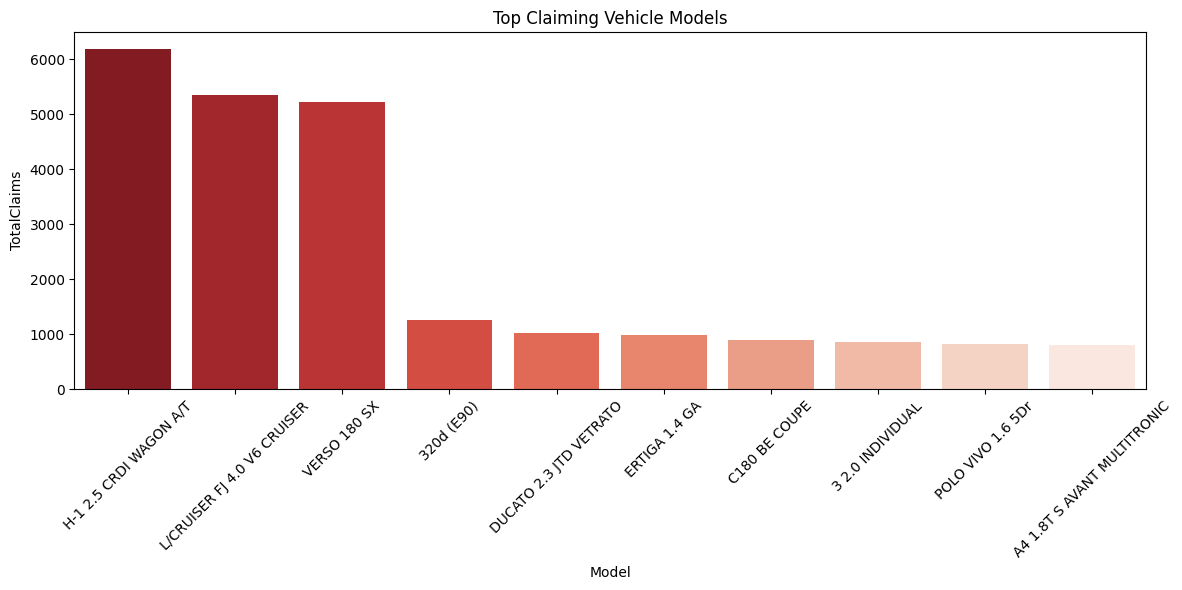


🚙 Lowest Claiming Models:
         make                            Model  TotalClaims
0  MITSUBISHI                    LANCER 1.6 GL          0.0
1      SCANIA            P 94LA 4X2 NA T/T C/C          0.0
2      SCANIA       F94 MARCO POLO BUS B/S B/S          0.0
3     RENAULT        SCENIC II AUTHENTIQUE 1.6          0.0
4     RENAULT        SCENIC 1.9 dCi EXPRESSION          0.0
5     RENAULT           SCENIC 1.4 AUTHENTIQUE          0.0
6      PROTON                  SAVVY 1.2 SPORT          0.0
7      PROTON                     GEN 2 1.6 GL          0.0
8     PEUGEOT  BOXER L4H2 3.0 HDi XLH4 F/C P/V          0.0
9     PEUGEOT  BOXER L4H2 2.2 HDi XLH4 F/C P/V          0.0


c:\ME\KAIM\acis-insurance-risk-analytics\src\data_visualizer.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="TotalClaims", data=bottom, palette="Blues")


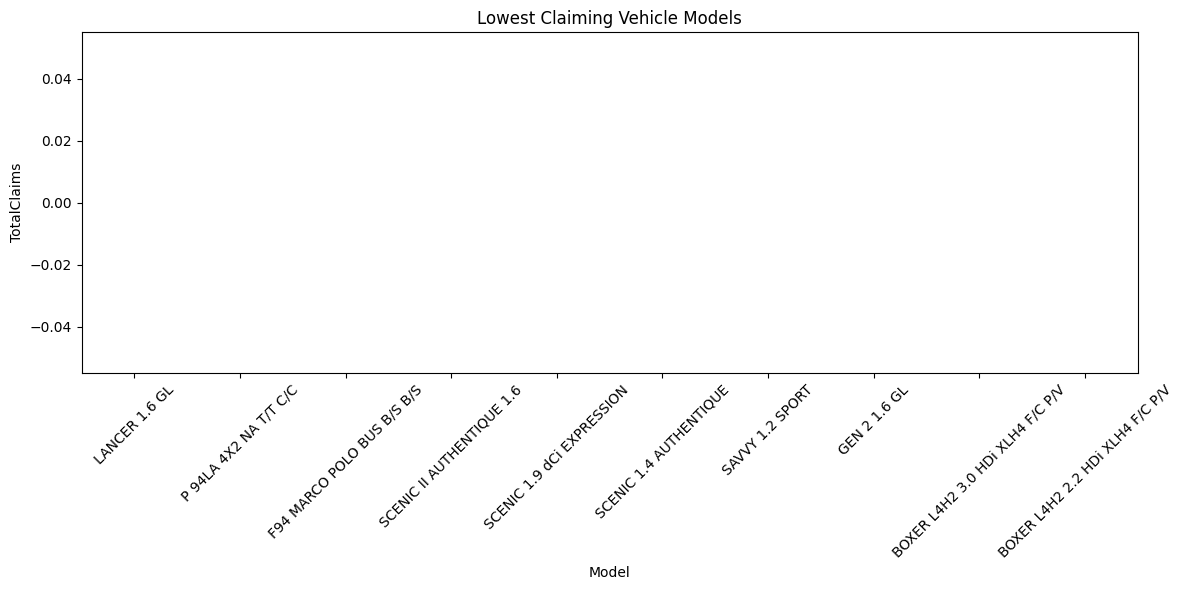

In [23]:
plot_top_and_bottom_models_by_claims(df)